In [1]:
from google.colab import drive
drive.mount('/content/gdrive')
%cd /content/gdrive/MyDrive/'Colab Notebooks'/DNA_Final1
!ls

Mounted at /content/gdrive
/content/gdrive/MyDrive/Colab Notebooks/DNA_Final1
 all_traj_DNAonly.npz		 eval_input.xyz
 checkpoints			 logs
 Conditional_RealNVP.ipynb	 merged_data.npz
 cond_seq_0.pdb			 mlp_seq_100.pdb
 cond_seq_1.5.pdb		 mlp_seq_120.pdb
 cond_seq_1.5_relaxed.pdb	 mlp_seq_140.pdb
 cond_seq_-18_relaxed.pdb	 mlp_seq_140_unrelaxed.pdb
 cond_seq_18_relaxed.pdb	'RealNVP with MLP.ipynb'
 cond_seq_1.pdb			 results
 cond_seq_-1_relaxed.pdb	 stretch1.rst7
 cond_seq_1_relaxed.pdb		 stretch2.rst7
 cond_seq_2.4_relaxed.pdb	 stretch3.rst7
 cond_seq_3.5_relaxed.pdb	 stretch4.rst7
 cond_seq_4.5_relaxed.pdb	 topology1.prmtop
 dna_mace_allfloat32.pt		 topology2.prmtop
 dna_mace_compiled.model	 topology3.prmtop
 dna_mace_dataset.xyz		 topology4.prmtop
 dna_mace_fixed.pt		 topology.prmtop
 dna_mace.model			 V1.ipynb
 E0s.txt			 V2.ipynb
 energies_all_list05.json	 V3.ipynb
 energies_all_list15.json	 V4.ipynb
 energies_all_list_low-05.json	 V5.ipynb
 energies_all_list_low-15.json	 valid_indi

In [2]:
!pip install netCDF4
!pip install parmed
!pip install openmm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 76.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 52.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.2/20.2 MB 124.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for parmed: filename=ParmEd-4.3.0-cp312-cp312-linux_x86_64.whl size=19471510 sha256=5ae407f9c21c7ef3ee1def98a99ae6ee08df23dc57c2030986cdb5252f25eb02
  Stored in directory: /root/.cache/pip/wheels/a3/c6/57/3ff4e09a91685738568d531ee739797913dd13b3553e202234
Successfully built parmed
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.3/14.3 MB 60.6 MB/s eta 0:00:00


In [3]:
import os
import re
import tqdm
import netCDF4
import numpy as np
import parmed as pmd
from tqdm import tqdm

import math
import pickle
import argparse
from sys import exit
from sklearn import datasets
import matplotlib.pyplot as plt

import openmm
from openmm import app, openmm
from openmm import unit, LangevinIntegrator
from openmm.app import AmberPrmtopFile, Simulation

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.init as init
import torch.nn.functional as F
import torch.nn.functional as functional
from torch.utils.data import DataLoader, TensorDataset

torch.set_default_dtype(torch.float32)

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [5]:
data = np.load("all_traj_DNAonly.npz")

coords = data["coords"]
boxes  = data["boxes"]

print("coords shape:", coords.shape)
print("boxes shape :", boxes.shape)

coords shape: (8050, 1894, 3)
boxes shape : (8050, 3)


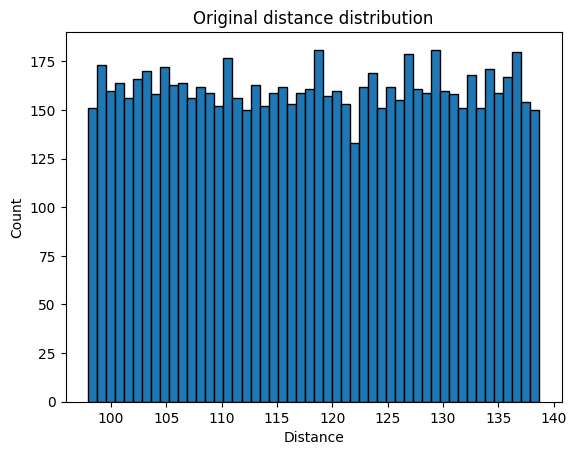

In [6]:
p1, p2, p3, p4 = 30, 943, 946, 1871

def middlePoint(one, two):
    return (one + two) / 2.0

def dist(one, two):
    return math.sqrt(np.sum((one - two)**2))

def compute_distances(trajectories, p1, p2, p3, p4):
    distances = []
    for coords in trajectories:
        leftEnd  = middlePoint(coords[p1], coords[p4])
        rightEnd = middlePoint(coords[p2], coords[p3])
        distances.append(dist(leftEnd, rightEnd))
    return torch.tensor(distances, dtype=torch.float32).unsqueeze(1)

distances_orig = compute_distances(coords, p1, p2, p3, p4)

plt.hist(distances_orig.numpy(), bins=50, edgecolor='black')
plt.title("Original distance distribution")
plt.xlabel("Distance")
plt.ylabel("Count")
plt.show()

In [7]:
coords_np = coords.astype(np.float32)
coords_flat = coords_np.reshape(8050, -1)
coords_flat = torch.from_numpy(coords_flat)
D = coords_flat.shape[1]
print("Flattened dimension D:", D)

Flattened dimension D: 5682


In [8]:
x_train_full = coords_flat
x_mean = x_train_full.mean(dim=0, keepdim=True)
x_std  = x_train_full.std(dim=0, keepdim=True) + 1e-6

x_all_norm = (coords_flat - x_mean) / x_std


In [9]:
c_all = distances_orig
c_train_full = c_all
c_mean = c_train_full.mean(dim=0, keepdim=True)
c_std  = c_train_full.std(dim=0, keepdim=True) + 1e-6

c_all_norm = (c_all - c_mean) / c_std


In [10]:
train_x = x_all_norm
train_c = c_all_norm

print("train_x:", train_x.shape, "train_c:", train_c.shape)

train_x: torch.Size([8050, 5682]) train_c: torch.Size([8050, 1])


In [11]:
batch_size = 16

train_ds = TensorDataset(train_x)
train_loader = DataLoader(train_ds, batch_size=batch_size,
                          shuffle=True, drop_last=True)


In [12]:
class CouplingLayer(nn.Module):
    def __init__(self, dim, hidden_dim, mask):
        super().__init__()
        self.dim = dim
        self.register_buffer("mask", mask.float())

        input_dim = dim

        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, dim * 2),
        )

    def forward(self, x):
        m = self.mask.to(x.device)
        x_masked = x * m

        inp = x_masked
        s, t = self.net(inp).chunk(2, dim=1)
        s = torch.tanh(s) * 1.5
        scale = torch.exp(s)

        y = x_masked + (1 - m) * (x * scale + t)
        logdet = ((1 - m) * s).sum(dim=1)
        return y, logdet

    def inverse(self, y):
        m = self.mask.to(y.device)
        y_masked = y * m

        inp = y_masked
        s, t = self.net(inp).chunk(2, dim=1)

        s = torch.tanh(s) * 1.5
        scale = torch.exp(s)

        x = y_masked + (1 - m) * ((y - t) / scale)
        logdet = -((1 - m) * s).sum(dim=1)
        return x, logdet


In [13]:
class RealNVP(nn.Module):
    def __init__(self, dim, n_layers=6, hidden_dim=512):
        super().__init__()
        self.dim = dim

        masks = []
        for i in range(n_layers):
            mask = torch.zeros(dim)
            mask[i % 2 :: 2] = 1.0
            masks.append(mask)

        self.layers = nn.ModuleList([
            CouplingLayer(dim, hidden_dim, masks[i])
            for i in range(n_layers)
        ])

    def forward(self, x):
        logdet_sum = torch.zeros(x.shape[0], device=x.device)
        z = x
        for layer in self.layers:
            z, logdet = layer(z)
            logdet_sum += logdet
        return z, logdet_sum

    def inverse(self, z):
        logdet_sum = torch.zeros(z.shape[0], device=z.device)
        x = z
        for layer in reversed(self.layers):
            x, logdet = layer.inverse(x)
            logdet_sum += logdet
        return x, logdet_sum


In [14]:
model = RealNVP(dim=D, n_layers=6, hidden_dim=512).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)


In [15]:
def flow_nll(model, x):
    z, logdet = model(x)
    log_pz = -0.5 * torch.sum(z**2, dim=1)
    log_px = log_pz + logdet
    nll = -log_px.mean()
    return nll

In [16]:
n_epochs = 200
for epoch in range(1, n_epochs + 1):
    model.train()
    train_loss = 0.0

    for (x_batch,) in train_loader:
        x_batch = x_batch.to(device)

        optimizer.zero_grad()
        loss = flow_nll(model, x_batch)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * x_batch.size(0)

    train_loss /= len(train_loader.dataset)
    print(f"Epoch {epoch:03d} | train NLL: {train_loss:.4f}")


Epoch 001 | train NLL: -1664.0599
Epoch 002 | train NLL: -4496.6028
Epoch 003 | train NLL: -5502.8134
Epoch 004 | train NLL: -6128.7783
Epoch 005 | train NLL: -6608.2520
Epoch 006 | train NLL: -6988.2161
Epoch 007 | train NLL: -7329.7230
Epoch 008 | train NLL: -7598.5556
Epoch 009 | train NLL: -7853.1836
Epoch 010 | train NLL: -8072.0938
Epoch 011 | train NLL: -8282.1001
Epoch 012 | train NLL: -8436.8629
Epoch 013 | train NLL: -8596.6808
Epoch 014 | train NLL: -8748.6047
Epoch 015 | train NLL: -8923.5644
Epoch 016 | train NLL: -9039.8915
Epoch 017 | train NLL: -9162.0851
Epoch 018 | train NLL: -9292.7131
Epoch 019 | train NLL: -9375.8052
Epoch 020 | train NLL: -9499.9700
Epoch 021 | train NLL: -9600.2558
Epoch 022 | train NLL: -9693.0614
Epoch 023 | train NLL: -9781.3783
Epoch 024 | train NLL: -9877.2974
Epoch 025 | train NLL: -9947.4326
Epoch 026 | train NLL: -10026.0607
Epoch 027 | train NLL: -10101.3472
Epoch 028 | train NLL: -10183.4328
Epoch 029 | train NLL: -10268.0732
Epoch 030 

In [17]:
model.eval()

with torch.no_grad():
    z, _ = model(train_x.to(device))
    z = z.cpu()

z_tensor = z.clone()
print("z_tensor shape:", z_tensor.shape)


z_tensor shape: torch.Size([8050, 5682])


In [18]:
cond_tensor = train_c.cpu()

from torch.utils.data import TensorDataset, DataLoader

map_ds = TensorDataset(cond_tensor, z_tensor)
map_loader = DataLoader(map_ds, batch_size=64, shuffle=True)

In [19]:
D = z_tensor.shape[1]

mlp = nn.Sequential(
    nn.Linear(1, 128),
    nn.ReLU(),
    nn.Linear(128, 256),
    nn.ReLU(),
    nn.Linear(256, 512),
    nn.ReLU(),
    nn.Linear(512, 512),
    nn.ReLU(),
    nn.Linear(512, D)
).to(device)

criterion = nn.MSELoss()
optimizer = optim.Adam(mlp.parameters(), lr=1e-3)

In [20]:
epochs = 80
for epoch in range(epochs):
    mlp.train()
    epoch_loss = 0.0

    for c_batch, z_batch in map_loader:
        c_batch = c_batch.to(device)
        z_batch = z_batch.to(device)

        optimizer.zero_grad()
        outputs = mlp(c_batch)
        loss = criterion(outputs, z_batch)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item() * c_batch.size(0)

    epoch_loss /= len(map_loader.dataset)

    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {epoch_loss:.6f}")

Epoch [10/80], Loss: 0.787810
Epoch [20/80], Loss: 0.782927
Epoch [30/80], Loss: 0.779170
Epoch [40/80], Loss: 0.776189
Epoch [50/80], Loss: 0.773556
Epoch [60/80], Loss: 0.771856
Epoch [70/80], Loss: 0.769913
Epoch [80/80], Loss: 0.769012


In [21]:
def sample_structs(c_norm, n_samples=1):

    model.eval()
    mlp.eval()

    with torch.no_grad():

        c_batch = torch.full(
            (n_samples, 1),
            fill_value=float(c_norm),
            dtype=torch.float32,
            device=device,
        )

        z_pred = mlp(c_batch)
        x_norm, _ = model.inverse(z_pred)

        x_mean_dev = x_mean.to(device)
        x_std_dev  = x_std.to(device)

        x = x_norm * x_std_dev + x_mean_dev
        x = x.view(n_samples, 1894, 3)
        x_np = x.cpu().numpy()

    return x_np


In [22]:
import time
import numpy as np
import parmed as pmd
from openmm import unit, openmm
from openmm import app

def minimize_coords_with_openmm(
    coords,
    top_file,
    rst_file,
    n_atoms_keep=1894,
    use_gb=True,
    max_iterations=500,
    tolerance=None,
    platform_name=None,  # "CUDA", "OpenCL", "CPU"
):

    coords = np.asarray(coords)
    assert coords.shape == (1, n_atoms_keep, 3), \
        f"coords must be shape (1, {n_atoms_keep}, 3), got {coords.shape}"

    if tolerance is None:
        tolerance = 10.0 * unit.kilojoules_per_mole / unit.nanometer

    print("Setting up OpenMM system for minimization...")
    structure = pmd.load_file(top_file, rst_file)[:n_atoms_keep]

    system = structure.createSystem(
        nonbondedMethod=app.CutoffNonPeriodic,
        nonbondedCutoff=1.2 * unit.nanometer,
        constraints=None,
        implicitSolvent=app.OBC2 if use_gb else None,
    )
    topology = structure.topology

    print("Forces present in system:")
    for i, f in enumerate(system.getForces()):
        print(f"  [{i}] {f.__class__.__name__}")

    integrator = openmm.VerletIntegrator(1.0 * unit.femtoseconds)

    if platform_name is not None:
        platform = openmm.Platform.getPlatformByName(platform_name)
        simulation = app.Simulation(topology, system, integrator, platform)
        print(f"Using platform: {platform_name}")
    else:
        simulation = app.Simulation(topology, system, integrator)
        platform = simulation.context.getPlatform()
        print(f"Using platform: {platform.getName()}")


    coords_nm = coords[0] * 0.1
    simulation.context.setPositions(coords_nm)


    state0 = simulation.context.getState(getEnergy=True)
    E0 = state0.getPotentialEnergy().value_in_unit(unit.kilocalorie_per_mole)
    print(f"Initial potential energy: {E0:.2f} kcal/mol")

    print(
        f"Starting minimization (max_iterations={max_iterations}, "
        f"tolerance={tolerance})"
    )
    t0 = time.perf_counter()
    simulation.minimizeEnergy(tolerance=tolerance, maxIterations=max_iterations)
    t1 = time.perf_counter()
    elapsed = t1 - t0
    print(f"Minimization finished in {elapsed:.2f} s")


    state = simulation.context.getState(getPositions=True, getEnergy=True)
    E_final = state.getPotentialEnergy().value_in_unit(unit.kilocalorie_per_mole)
    print(f"Final potential energy:   {E_final:.2f} kcal/mol")


    positions_nm = state.getPositions(asNumpy=True).value_in_unit(unit.nanometer)
    coords_min_angs = np.array(positions_nm) * 10.0
    coords_min_angs = coords_min_angs[np.newaxis, ...]

    return coords_min_angs, E0, E_final, elapsed

In [23]:
def save_generated_pdb(
    coords,
    topology_file="topology1.prmtop",
    rst_file="stretch1.rst7",
    n_atoms_keep=1894,
    out_file="generated_sample.pdb",
    relax=False,
    use_gb=True,
    max_iterations=500,
    tolerance=None,
    platform_name=None,
):

    coords = np.asarray(coords)
    assert coords.shape == (1, n_atoms_keep, 3), \
        f"coords must be shape (1, {n_atoms_keep}, 3), got {coords.shape}"

    if relax:
        print("=== Running OpenMM minimization before saving PDB ===")
        coords_relaxed, E0, E_final, elapsed = minimize_coords_with_openmm(
            coords=coords,
            top_file=topology_file,
            rst_file=rst_file,
            n_atoms_keep=n_atoms_keep,
            use_gb=use_gb,
            max_iterations=max_iterations,
            tolerance=tolerance,
            platform_name=platform_name,
        )
        coords_to_save = coords_relaxed
        print(
            f"Energy change: {E0:.2f} → {E_final:.2f} kcal/mol "
            f"(ΔE = {E_final - E0:.2f} kcal/mol)"
        )
        print(f"Minimization time: {elapsed:.2f} s")
    else:
        coords_to_save = coords
        print("Skipping minimization; saving raw generated coordinates.")

    full = pmd.load_file(topology_file, rst_file)
    print(f"Full structure atoms:   {len(full.atoms)}")

    trimmed = full[:n_atoms_keep]
    print(f"Trimmed structure atoms: {len(trimmed.atoms)}")

    trimmed.coordinates = coords_to_save[0]

    os.makedirs(os.path.dirname(out_file) or ".", exist_ok=True)

    trimmed.save(out_file, overwrite=True)
    print(f"✅ Saved PDB: {out_file}")

    return trimmed

In [24]:
def distance_to_norm(d_raw):
    return float((d_raw - c_mean.item()) / c_std.item())

In [25]:
c_norm = distance_to_norm(d_raw=140)
coords_gen = sample_structs(c_norm=c_norm, n_samples=1)[0]
coords_gen = coords_gen[np.newaxis, ...]

In [26]:
print(coords_gen)

[[[30.826963 20.592484 21.410675]
  [31.269903 20.940472 21.504295]
  [31.052208 22.295076 21.492517]
  ...
  [32.57419  32.993748 22.402365]
  [33.62698  37.61409  21.305914]
  [33.450275 38.46177  20.710825]]]


In [27]:
pdb_struct = save_generated_pdb(
    coords=coords_gen,
    topology_file="topology1.prmtop",
    rst_file="stretch1.rst7",
    n_atoms_keep=1894,
    out_file="mlp_seq_140_unrelaxed.pdb",
    relax=True,
    use_gb=True,
    max_iterations=500,
    platform_name="OpenCL",
)

=== Running OpenMM minimization before saving PDB ===
Setting up OpenMM system for minimization...
Forces present in system:
  [0] HarmonicBondForce
  [1] HarmonicAngleForce
  [2] PeriodicTorsionForce
  [3] NonbondedForce
  [4] CustomGBForce
  [5] CMMotionRemover
Using platform: OpenCL
Initial potential energy: 2805266.17 kcal/mol
Starting minimization (max_iterations=500, tolerance=10.0 kJ/(nm mol))
Minimization finished in 0.54 s
Final potential energy:   -17529.24 kcal/mol
Energy change: 2805266.17 → -17529.24 kcal/mol (ΔE = -2822795.41 kcal/mol)
Minimization time: 0.54 s
Full structure atoms:   70688
Trimmed structure atoms: 1894
✅ Saved PDB: mlp_seq_140_unrelaxed.pdb
